# Entrainement des modèles de ML : Version 0 : Dumb models

#### - Modèle 1 : Logistic Regression
#### - Modèle 2 : Random Forest

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
from plotly.subplots import make_subplots

In [2]:
clean_train_dataset = pd.read_csv("dataset_clean_with_clusters.csv")

In [3]:
### 
# Modele numéro 1 : Logistic Regression
###

In [4]:
train_dataset = clean_train_dataset.drop(columns=["kmeans_cluster", "dbscan_cluster"])
train_dataset.head()

,country,age,new_user,source,total_pages_visited,converted
0,Germany,32,1,Direct,7,0
1,US,28,1,Ads,7,0
2,China,18,1,Seo,8,0
3,US,26,1,Seo,5,1
4,US,20,1,Ads,2,0


In [5]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   country              10000 non-null  object
 1   age                  10000 non-null  int64 
 2   new_user             10000 non-null  int64 
 3   source               10000 non-null  object
 4   total_pages_visited  10000 non-null  int64 
 5   converted            10000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 468.9+ KB


In [6]:
# split du dataset

In [7]:
X = train_dataset.drop(columns=["converted"])
y = train_dataset["converted"]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
#preprocessing logistic regression 

numeric_features = ["age", "total_pages_visited"]
categorical_features = ["country", "source", "new_user"] # new_user est à exclure car déjà un int64 ? 

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [10]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [11]:
params = {"C": 1.0, "solver": "lbfgs", "max_iter": 100}

lr_model = LogisticRegression(random_state=42, **params)

lr_model.fit(x_train_processed, y_train)
y_pred = lr_model.predict(x_test_processed)

f1 = f1_score(y_test, y_pred)
accuracy = lr_model.score(x_test_processed, y_test)
cm = confusion_matrix(y_test, y_pred)

print(f"F1 Score: {f1}")
# print(f"Accuracy: {accuracy}") Accuracy n'est pas un bon indicateur pour les datasets déséquilibrés. 
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(cm)

F1 Score: 0.7868852459016393
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2898
           1       0.89      0.71      0.79       102

    accuracy                           0.99      3000
   macro avg       0.94      0.85      0.89      3000
weighted avg       0.99      0.99      0.99      3000

Confusion Matrix:
[[2889    9]
 [  30   72]]


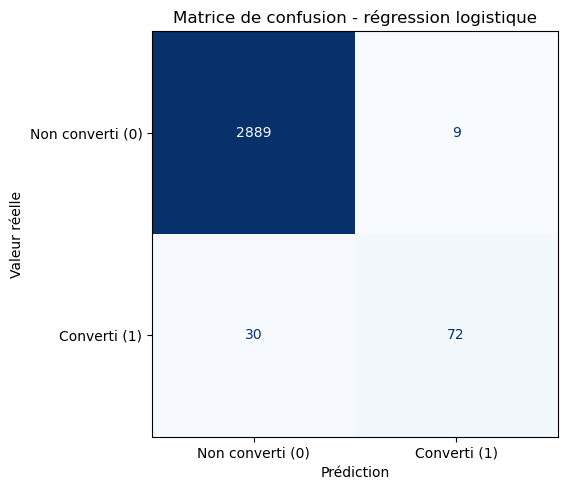

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non converti (0)", "Converti (1)"]
)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)

ax.set_title("Matrice de confusion - régression logistique")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Valeur réelle")
plt.tight_layout()
plt.show()

In [13]:
###
# modele numéro 2 : Random Forest Classifier
###

In [14]:
rf_model = RandomForestClassifier()

rf_model.fit(x_train_processed, y_train)
y_pred_rf = rf_model.predict(x_test_processed)

f1_rf = f1_score(y_test, y_pred_rf)
accuracy_rf = rf_model.score(x_test_processed, y_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"F1 Score (Random Forest): {f1_rf}")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix (Random Forest):")
print(cm_rf)

F1 Score (Random Forest): 0.6974358974358974
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2898
           1       0.73      0.67      0.70       102

    accuracy                           0.98      3000
   macro avg       0.86      0.83      0.84      3000
weighted avg       0.98      0.98      0.98      3000

Confusion Matrix (Random Forest):
[[2873   25]
 [  34   68]]


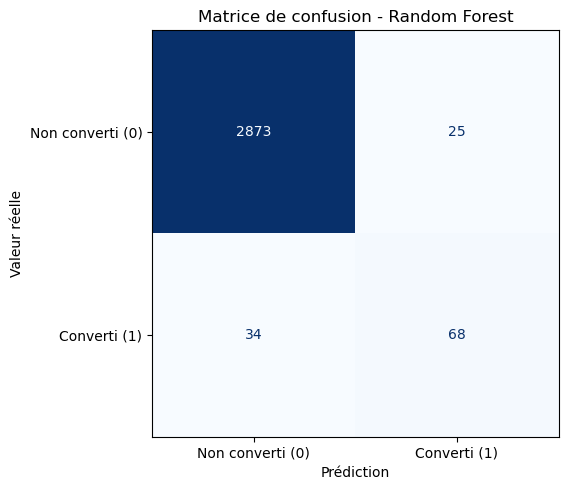

In [15]:
cm_rf= confusion_matrix(y_test, y_pred_rf, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non converti (0)", "Converti (1)"]
)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)

ax.set_title("Matrice de confusion - Random Forest")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Valeur réelle")
plt.tight_layout()
plt.show()

### Comparaison des performances des modèles deux modèles : 

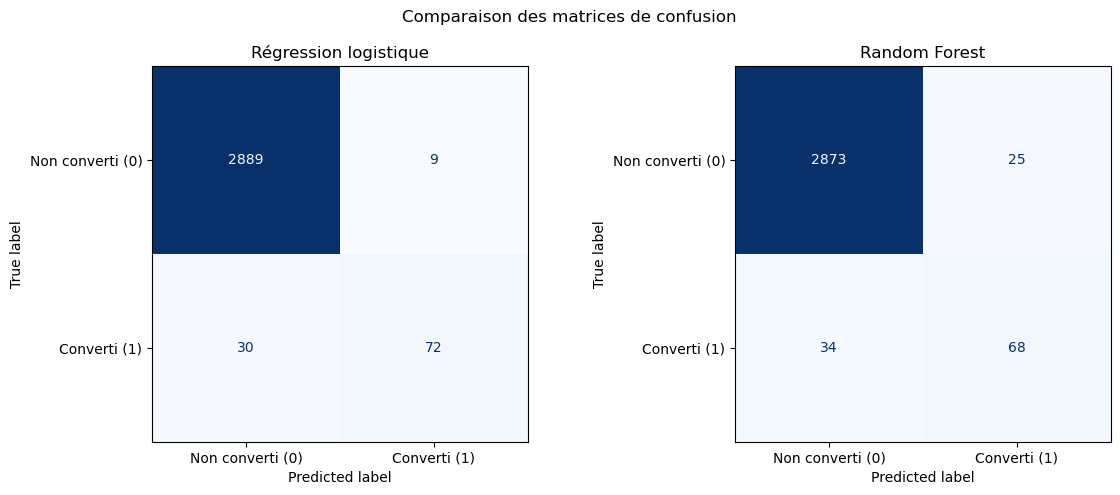

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non converti (0)", "Converti (1)"]
)
disp_lr.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Régression logistique")

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non converti (0)", "Converti (1)"]
)
disp_rf.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Random Forest")

# Même échelle de couleurs pour faciliter la comparaison
vmax = max(cm.max(), cm_rf.max())
disp_lr.im_.set_clim(0, vmax)
disp_rf.im_.set_clim(0, vmax)

fig.suptitle("Comparaison des matrices de confusion")
plt.tight_layout()
plt.show()

#### =>> En version dumb model, le modèle le plus performant est le modèle Logistic Regression :  
- Le modèle de Logistic regression affiche un F1 score de 0.764 et un recall de 0.69. 
- Le modèle Random Forest affiche un F1 score de 0.734 et un recall de 0.67. 

# To do : faire la cross validation des entrainements des modèles Logistic Regression et Random Forest afin de trouver les meilleurs hyperparamètres pour chaque modèle.

In [17]:
from sklearn.model_selection import StratifiedKFold

# Le choix de StratifiedKFold est pertinent ici car il permet de maintenir la proportion des classes dans chaque fold, 
# ce qui est crucial pour les problèmes de classification déséquilibrée comme celui-ci. 
cv = StratifiedKFold( 
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
#preprocessing logistic regression 

numeric_features = ["age", "total_pages_visited"]
categorical_features = ["country", "source", "new_user"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [19]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [20]:
params_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
    "solver": ["liblinear", "lbfgs"]
}

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

grid_lr = GridSearchCV(
    estimator=model,
    param_grid=params_lr,
    scoring=["f1", "recall"],
    refit="f1",
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(x_train_processed, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'solver': ['liblinear', 'lbfgs']},
             refit='f1', scoring=['f1', 'recall'])

In [22]:
grid_lr.best_params_

{'C': 10, 'class_weight': None, 'solver': 'liblinear'}

#### Les hyperparamètres à tester pour le modèle de régression logistique sont les suivants :
- La pondération des features explicatives (class_weight) : Le nombre de pages visitées, le pays d'origine et l'âge sont des variables explicatives avec un impact différent sur la conversion. Il faudra donc tester différents poids pour ces features afin de trouver la meilleure combinaison pour le modèle de régression logistique. vu lors de l'EDA.